# Assignment 4

Deadline: 13.05.2026, 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

In [2]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [3]:
PATH_TO_DATA = os.path.join(project_root, 'qpmwp-course', 'data') + os.sep
SAVE_PATH = PATH_TO_DATA

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [4]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path=f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path=f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path=PATH_TO_DATA)

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data,
    jkp_data=jkp_data,
)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [5]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [6]:
JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

# Investment
JKP_FIELDS_THEME_1 = [
    'at_gr1',
    'ppeinv_gr1a',
    'noa_gr1a',
    'lnoa_gr1a',
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'inv_gr1',
    'inv_gr1a',
    'coa_gr1a',
    'col_gr1a',
    'nfna_gr1a',
    'fnl_gr1a',
]

# Profitability
JKP_FIELDS_THEME_2 = [
    'ni_be',
    'niq_be',
    'niq_at',
    'ebit_bev',
    'ebit_sale',
    'sale_bev',
    'gp_at',
    'gp_atl1',
    'op_at',
    'op_atl1',
    'cop_at',
    'cop_atl1',
    'f_score',
]

# Low risk
JKP_FIELDS_THEME_3 = [
    'ivol_ff3_21d',
    'ivol_capm_252d',
    'ivol_capm_21d',
    'rvol_21d',
    'beta_60m',
    'betabab_1260d',
    'beta_dimson_21d',
    'corr_1260d',
    'rmax1_21d',
    'rmax5_21d',
    'betadown_252d',
]


JKP_FIELDS = {
    'quality': JKP_FIELDS_QUALITY,
    'value': JKP_FIELDS_VALUE,
    'momentum': JKP_FIELDS_MOMENTUM,
    'investment': JKP_FIELDS_THEME_1,
    'profitability': JKP_FIELDS_THEME_2,
    'low_risk': JKP_FIELDS_THEME_3,
}

REVERSED_THEMES = [
    'investment',
    'low_risk',
]

JKP_SCORE_FIELDS = {
    factor_theme: [f'{factor_theme}_score']
    for factor_theme in JKP_FIELDS.keys()
}

for factor_theme, fields in JKP_FIELDS.items():

    signed_data = jkp_data[fields].copy()

    if factor_theme in REVERSED_THEMES:
        signed_data = -signed_data

    ranked_data = signed_data.groupby(level='date').rank(pct=True)

    jkp_data[f'{factor_theme}_score'] = ranked_data.mean(axis=1)

data.jkp_data = jkp_data

## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.

- Simulate the return streams for both backtests and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

Running factor theme: quality


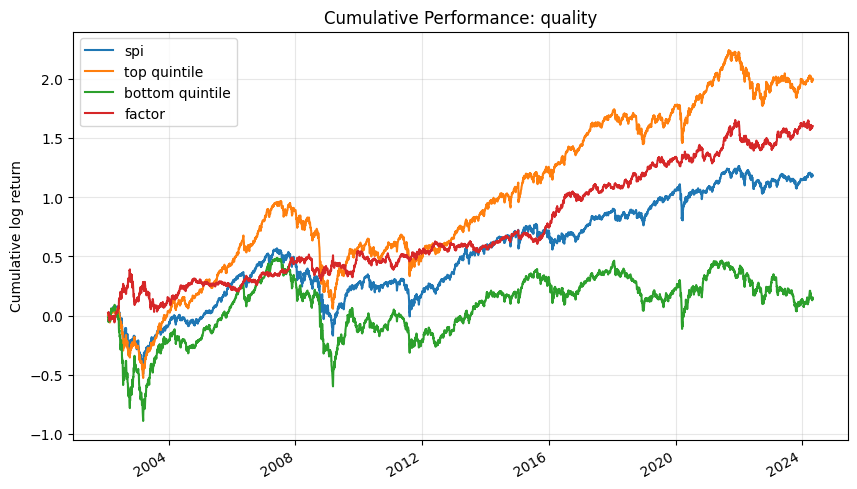

Running factor theme: value


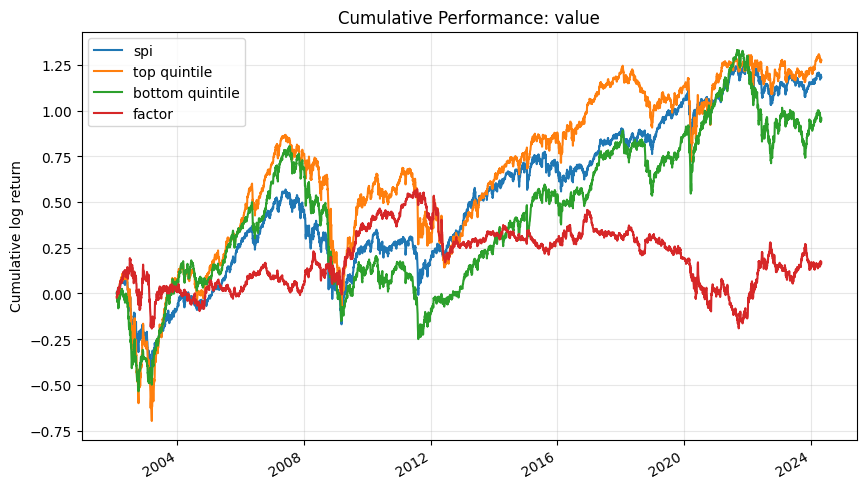

Running factor theme: momentum


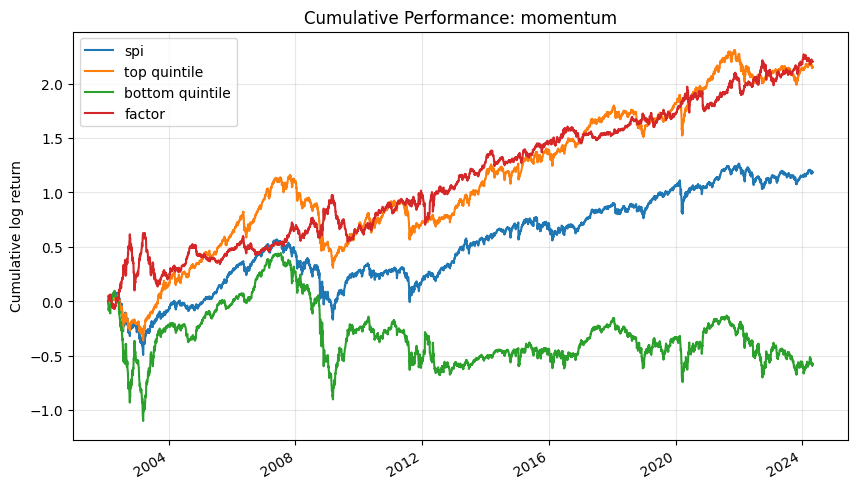

Running factor theme: investment


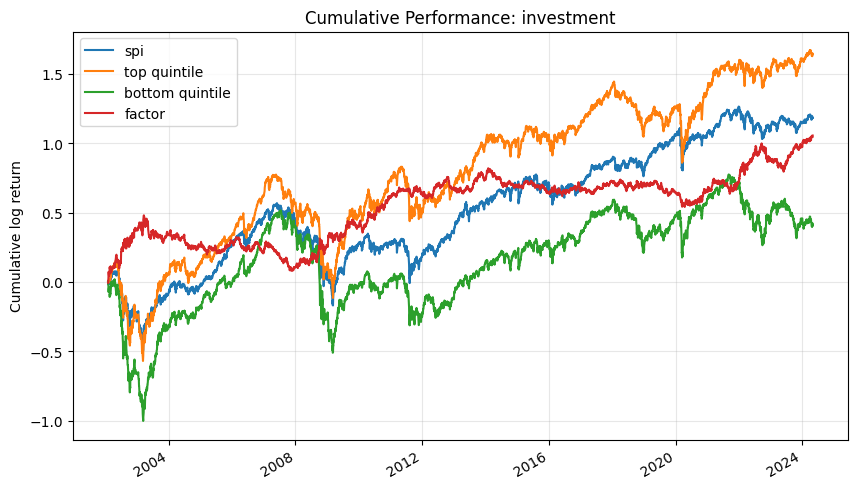

Running factor theme: profitability


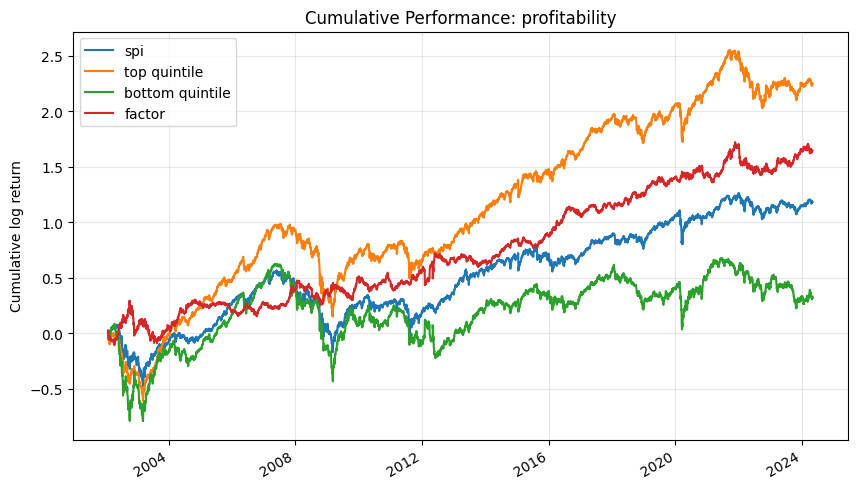

Running factor theme: low_risk


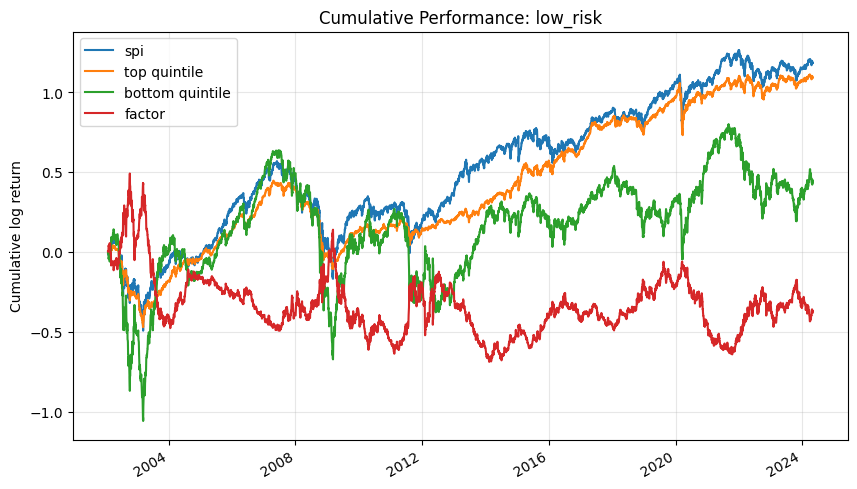

In [7]:
import matplotlib.pyplot as plt

fixed_costs = 0
variable_costs = 0
return_series = data.get_return_series()

factor_results = {}
top_quintile_returns = {}
bottom_quintile_returns = {}
factor_returns = {}

for factor_theme, fields in JKP_SCORE_FIELDS.items():

    print(f"Running factor theme: {factor_theme}")

    selection_item_builders = {
        'min_volume': SelectionItemBuilder(
            bibfn=bibfn_selection_min_volume,
            width=365,
            min_volume=500_000,
            agg_fn=np.median,
        ),
        'jkp_data_scores': SelectionItemBuilder(
            bibfn=bibfn_selection_jkp_data_scores,
            fields=fields,
        ),
    }

    optimization_item_builders = {
        'scores': OptimizationItemBuilder(
            bibfn=bibfn_scores,
            fields=fields,
        ),
    }

    # Top quintile portfolio
    bs_tqp = BacktestService(
        data=data,
        selection_item_builders=selection_item_builders,
        optimization_item_builders=optimization_item_builders,
        optimization=PercentilePortfolio(
            percentile=80,
            sign='>=',
        ),
        rebdates=rebdates,
        quiet=True,
    )

    bt_tqp = Backtest()
    bt_tqp.run(bs=bs_tqp)

    # Bottom quintile portfolio
    bs_bqp = BacktestService(
        data=data,
        selection_item_builders=selection_item_builders,
        optimization_item_builders=optimization_item_builders,
        optimization=PercentilePortfolio(
            percentile=20,
            sign='<=',
        ),
        rebdates=rebdates,
        quiet=True,
    )

    bt_bqp = Backtest()
    bt_bqp.run(bs=bs_bqp)

    # Simulate return streams
    sim_tqp = bt_tqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs,
    )

    sim_bqp = bt_bqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs,
    )

    sim_factor = sim_tqp - sim_bqp

    factor_results[factor_theme] = {
        'top_quintile_backtest': bt_tqp,
        'bottom_quintile_backtest': bt_bqp,
        'top_quintile_returns': sim_tqp,
        'bottom_quintile_returns': sim_bqp,
        'factor_returns': sim_factor,
    }

    top_quintile_returns[factor_theme] = sim_tqp
    bottom_quintile_returns[factor_theme] = sim_bqp
    factor_returns[factor_theme] = sim_factor

    sim = pd.concat({
        'spi': data.bm_series,
        'top quintile': sim_tqp,
        'bottom quintile': sim_bqp,
        'factor': sim_factor,
    }, axis=1).dropna()

    ax = np.log(1 + sim).cumsum().plot(
        title=f'Cumulative Performance: {factor_theme}',
        figsize=(10, 6),
    )
    ax.set_ylabel('Cumulative log return')
    ax.grid(alpha=0.3)
    plt.show()

## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix series and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [8]:
# Factor-mix return series: average of all top-quintile portfolio return series
factor_mix_returns = pd.concat(top_quintile_returns, axis=1).mean(axis=1)

# Combine dependent variable, SPI, and factor return series
regression_data = pd.concat(
    {
        'factor_mix': factor_mix_returns,
        'spi': data.bm_series,
        **factor_returns,
    },
    axis=1,
).dropna()

# Convert daily returns to monthly returns
regression_data_monthly = regression_data.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
).dropna()

# Define dependent and independent variables
y = regression_data_monthly['factor_mix']
X = regression_data_monthly.drop(columns='factor_mix')

# Add constant
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(y, X)
results = model.fit()

# Print regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             factor_mix   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     241.0
Date:                Sat, 09 May 2026   Prob (F-statistic):          1.58e-109
Time:                        22:21:01   Log-Likelihood:                 722.83
No. Observations:                 267   AIC:                            -1430.
Df Residuals:                     259   BIC:                            -1401.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0021      0.001      1.896